## Pre-processing & Feature Engineering: E-Commerce Customer Behavior
**Role:** Data Engineer (Ibnu Dwiki Hermawan)

**Tujuan Notebook:**

1. Membersihkan data mentah dari *missing values* dan anomali transaksi.

2. Mengekstrak fitur RFM dan fitur tambahan (AvgSpending, UniqueProducts).

3. Menggunakan DBSCAN untuk menyaring *noise* / *outliers* sebelum masuk ke pemodelan K-Means.

In [56]:

# Import library esensial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [57]:
# Memuat dataset (Pastikan path file disesuaikan dengan folder struktur repositori)
# Jika diletakkan di folder 'data/raw/':
file_path = '../data/raw/data.csv'
df = pd.read_csv(file_path, encoding="ISO-8859-1")

print(f"Dimensi data awal: {df.shape}")
df.head()

Dimensi data awal: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 1. Data Cleaning
Menghapus baris tanpa `CustomerID`, transaksi dengan kuantitas negatif/nol, dan transaksi yang dibatalkan (berawalan huruf 'C').

In [58]:
# Hapus missing values pada CustomerID
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Dimensi data setelah dibersihkan: {df_clean.shape}")

Dimensi data setelah dibersihkan: (406829, 9)


## 2. Feature Engineering (RFM + Fitur Tambahan)
Menghitung Recency, Frequency, dan Monetary, serta menambahkan `UniqueProducts` (keragaman produk) dan `AvgSpending` (rata-rata pengeluaran per transaksi).

In [59]:
# a. Ekstraksi Fitur Pembatalan (Indikator Keraguan Pelanggan)
df_clean['IsCanceled'] = df_clean['InvoiceNo'].str.startswith('C')
cancellations = df_clean[df_clean['IsCanceled']].groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
cancellations.columns = ['CustomerID', 'CancelFrequency']

# b. Filter data sukses untuk RFM dasar
df_success = df_clean[(~df_clean['IsCanceled']) & (df_clean['Quantity'] > 0)].copy()
snapshot_date = df_success['InvoiceDate'].max() + timedelta(days=1)

# c. Agregasi RFM dan Fitur Lanjutan
customer_df = df_success.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    AvgSpending=('TotalPrice', 'mean'),
    UniqueProducts=('StockCode', 'nunique'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()

# d. Penggabungan & Perhitungan Rata-rata Bulanan
customer_df = customer_df.merge(cancellations, on='CustomerID', how='left')
customer_df['CancelFrequency'] = customer_df['CancelFrequency'].fillna(0)

# Hitung umur pelanggan dalam bulan (minimal 1 bulan)
customer_df['CustomerAgeMonths'] = ((customer_df['LastPurchase'] - customer_df['FirstPurchase']).dt.days / 30).clip(lower=1)
customer_df['AvgMonthlySpending'] = customer_df['Monetary'] / customer_df['CustomerAgeMonths']

# Drop kolom waktu yang tidak digunakan
customer_df = customer_df.drop(columns=['FirstPurchase', 'LastPurchase', 'CustomerAgeMonths'])
customer_df.set_index('CustomerID', inplace=True)

print("Fitur berhasil diekstrak. Dimensi data:", customer_df.shape)
display(customer_df.head())

Fitur berhasil diekstrak. Dimensi data: (4339, 7)


,Recency,Frequency,Monetary,AvgSpending,UniqueProducts,CancelFrequency,AvgMonthlySpending
CustomerID,,,,,,,
12346.0,326,1,77183.60,77183.600000,1,1.0,77183.600000
12347.0,2,7,4310.00,23.681319,103,0.0,354.246575
12348.0,75,4,1797.24,57.975484,22,0.0,191.195745
12349.0,19,1,1757.55,24.076027,73,0.0,1757.550000
12350.0,310,1,334.40,19.670588,17,0.0,334.400000


## 3. Scaling Data
Algoritma DBSCAN sangat sensitif terhadap skala jarak. Kita perlu menstandarisasi fitur menggunakan `StandardScaler`.

In [60]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_df)
scaled_df = pd.DataFrame(scaled_features, columns=customer_df.columns, index=customer_df.index)

scaled_df.head()

,Recency,Frequency,Monetary,AvgSpending,UniqueProducts,CancelFrequency,AvgMonthlySpending
CustomerID,,,,,,,
12346.0,2.334858,-0.424675,8.359634,52.546021,-0.708687,0.077461,46.673278
12347.0,-0.905199,0.354080,0.251046,-0.030405,0.486336,-0.388701,-0.057116
12348.0,-0.175186,-0.035297,-0.028546,-0.007038,-0.462653,-0.388701,-0.156289
12349.0,-0.735196,-0.424675,-0.032963,-0.030137,0.134858,-0.388701,0.796424
12350.0,2.174855,-0.424675,-0.191315,-0.033138,-0.521232,-0.388701,-0.069187


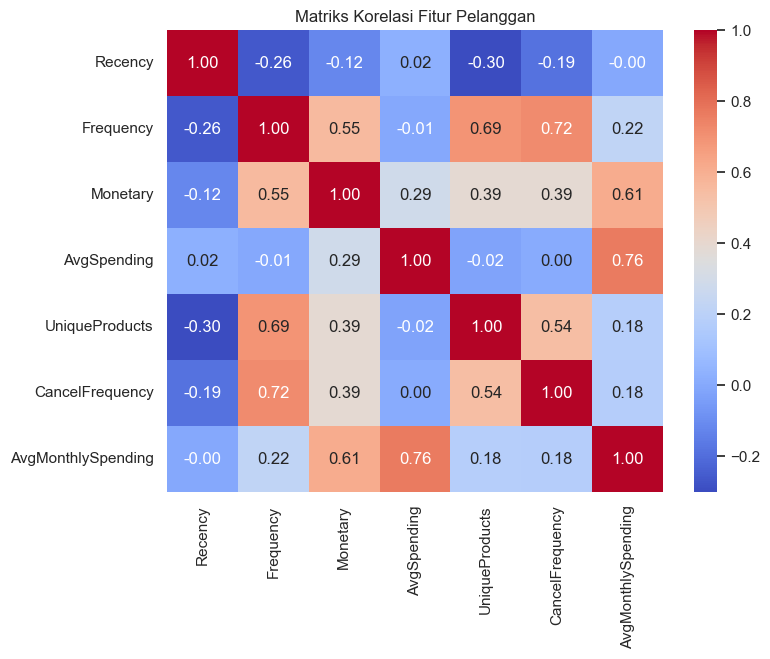

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat Heatmap Korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(customer_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi Fitur Pelanggan")
plt.show()

In [62]:
# 1. Transformasi Logaritma untuk mengatasi skewness yang ekstrem
cols_to_log = ['Recency', 'Frequency', 'Monetary', 'AvgSpending', 'UniqueProducts', 'CancelFrequency', 'AvgMonthlySpending']
customer_df_log = np.log1p(customer_df[cols_to_log])

# 2. Standarisasi Skala
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_df_log) # Gunakan data_log di sini
scaled_df = pd.DataFrame(scaled_features, columns=customer_df.columns, index=customer_df.index)

scaled_df.head()

,Recency,Frequency,Monetary,AvgSpending,UniqueProducts,CancelFrequency,AvgMonthlySpending
CustomerID,,,,,,,
12346.0,1.462236,-0.955013,3.696168,9.637284,-2.524597,0.556964,6.041382
12347.0,-2.038611,1.074523,1.408758,0.261594,0.965889,-0.644655,0.382016
12348.0,0.373310,0.386437,0.715517,1.276383,-0.367054,-0.644655,-0.264044
12349.0,-0.622914,-0.955013,0.697821,0.280077,0.665249,-0.644655,2.064144
12350.0,1.424800,-0.955013,-0.615877,0.055002,-0.583592,-0.644655,0.321555


In [68]:
# Cek skewness setelah Log dan Scaling
print("Skewness setelah Log & Scaling:")
print(scaled_df.skew())

Skewness setelah Log & Scaling:
Recency              -0.378677
Frequency             1.208917
Monetary              0.360562
AvgSpending           1.578632
UniqueProducts       -0.244288
CancelFrequency       1.649728
AvgMonthlySpending    0.275520
dtype: float64


## 4. DBSCAN untuk Filter Noise
Mendeteksi pelanggan yang memiliki pola transaksi anomali (*outliers*) agar tidak merusak klaster utama pada algoritma K-Means nanti.

In [64]:

# Inisialisasi dan fit model DBSCAN
# (Parameter eps dan min_samples bisa di-tuning lebih lanjut)
dbscan = DBSCAN(eps=1.5, min_samples=5)
customer_df['Cluster_DBSCAN'] = dbscan.fit_predict(scaled_df)

# Memisahkan Inliers (bersih) dan Outliers (noise)
clean_data = customer_df[customer_df['Cluster_DBSCAN'] != -1].copy()
noise_data = customer_df[customer_df['Cluster_DBSCAN'] == -1].copy()

# Buang kolom penanda DBSCAN dari data bersih
clean_data = clean_data.drop(columns=['Cluster_DBSCAN'])
noise_data = noise_data.drop(columns=['Cluster_DBSCAN'])

print(f"Jumlah Pelanggan Normal (Inliers): {len(clean_data)}")
print(f"Jumlah Pelanggan Anomali (Outliers): {len(noise_data)}")

Jumlah Pelanggan Normal (Inliers): 4283
Jumlah Pelanggan Anomali (Outliers): 56


## 5. Export Data
Menyimpan dataset yang sudah bersih untuk diteruskan ke tahap K-Means.

In [65]:
# Ekspor ke folder processed
clean_data.to_csv('../data/processed/clean_customer_features.csv')
noise_data.to_csv('../data/processed/anomalous_customers.csv')

print("Proses Data Engineering selesai. File CSV berhasil disimpan!")

Proses Data Engineering selesai. File CSV berhasil disimpan!
